# Phan Tich Convergence

Notebook nay chay lai 6 thuat toan: `NSGA_II`, `MOEA_D`, `PFG_MOEA`, `PFG_MOEA_D`, `NSGA_III`, `ALNSMO`. Voi moi nhom `C`, `R`, `RC`, notebook chon 1 instance co HV cua `PFG_MOEA_D` cao nhung max_time khong qua lau, tong cong 6 instance cho data100 va data200.

STEP 1 chay 6 thuat toan theo cung `max_time` doc tu `meta_info.csv` cua instance da chon trong root ket qua 5 thuat toan goc, roi luu log CSV. STEP 2 doc truc tiep CSV da luu va ve 6 duong HV convergence trong cung mot hinh PDF. HV duoc tinh tren cac diem Pareto da min-max normalize theo tung instance, voi reference point `[1.1, 1.1]`.


In [ ]:
import os
import re
import sys
import time
import random
from pathlib import Path

PROJECT_DIR = Path(r"D:\codePython\pythonProject\final_project\pfg_moead_vrpd_ver2")
os.chdir(PROJECT_DIR)
for path in [PROJECT_DIR.parent, PROJECT_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pfg_moead_vrpd_ver2.algorithm.nsgaii_solver import NSGA2Solver
from pfg_moead_vrpd_ver2.algorithm.moead_solver import MOEADSolver
from pfg_moead_vrpd_ver2.algorithm.pfg_moea_solver import PFGMOEASolver
from pfg_moead_vrpd_ver2.algorithm.pfg_moead_solver_stop import PFGMOEADSolverStop
from pfg_moead_vrpd_ver2.algorithm.nsgaiii_solver import NSGA3Solver
from pfg_moead_vrpd_ver2.algorithm.alnsmo_solver import ALNSMOSolver
from pfg_moead_vrpd_ver2.model.customer import Customer
from pfg_moead_vrpd_ver2.model.solution import Solution
from pfg_moead_vrpd_ver2.model.evaluator import Evaluator
from pfg_moead_vrpd_ver2.utils.pfg import build_pfg, sample_from_pfg

# CONFIG
POP_SIZE = 100
NUM_TRUCKS = 6
SEED = 1
BASE_ALGO = "PFG_MOEA_D"

ALGOS = ["NSGA_II", "MOEA_D", "PFG_MOEA", "PFG_MOEA_D", "NSGA_III", "ALNSMO"]

COLORS = {
    "NSGA_II": "#ff8c00",
    "MOEA_D": "#0066ff",
    "PFG_MOEA": "#00c853",
    "PFG_MOEA_D": "#ff1744",
    "NSGA_III": "#8e24aa",
    "ALNSMO": "#a65628",
}

# None = use max_time from meta_info.csv. Set a number of seconds for a quick test, e.g. TEST_MAX_TIME = 30.
TEST_MAX_TIME = None

OUTPUT_DIR = Path("convergence_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

DATASETS = {
    "data100": {
        "data_dir": "data",
        "summary_results": "summary_results_data100_new_ver2.xlsx",
        "result_root_5algo": "result_instance_5algo_with_stop_time_56",
    },
    "data200": {
        "data_dir": "200",
        "summary_results": "summary_results_data200_new_ver2.xlsx",
        "result_root_5algo": "result_instance_5algo_with_stop_time_56_data200",
    },
}


In [3]:
# DATA + METRIC HELPERS

def load_customers_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    customers = {}

    depot = df.iloc[0]
    customers[0] = Customer(
        cid=0,
        x=float(depot["x"]),
        y=float(depot["y"]),
        demand=0.0,
        ready_time=float(depot["open"]),
        due_time=float(depot["close"]),
        service_time=float(depot["servicetime"]),
        drone_serve=False,
        time=0.0,
    )

    for idx in range(1, len(df)):
        r = df.iloc[idx]
        customers[idx] = Customer(
            cid=idx,
            x=float(r["x"]),
            y=float(r["y"]),
            demand=float(r["demand"]),
            ready_time=float(r["open"]),
            due_time=float(r["close"]),
            service_time=float(r["servicetime"]),
            drone_serve=bool(r["drone_serve"]),
            time=float(r["time"]),
        )

    return customers


def get_group(instance_name):
    name = str(instance_name).upper()
    if "RC" in name:
        return "RC"
    if re.search(r"H\d+C", name):
        return "C"
    if re.search(r"H\d+R", name):
        return "R"
    return None


def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))


def to_folder_name(instance_name):
    name = str(instance_name)
    return name if name.startswith("result_") else f"result_{name}"


def read_meta_max_time(dataset_name, instance_name, algo=BASE_ALGO):
    cfg = DATASETS[dataset_name]
    meta_file = Path(cfg["result_root_5algo"]) / to_folder_name(instance_name) / "meta_info.csv"

    if not meta_file.exists():
        raise FileNotFoundError(f"Missing meta_info.csv: {meta_file}")

    meta = pd.read_csv(meta_file)
    row = meta[meta["algorithm"] == algo]
    if row.empty:
        raise ValueError(f"Algorithm {algo} not found in {meta_file}")

    return float(row.iloc[0]["max_time"]), meta_file


def pf_to_array(pf):
    if not pf:
        return np.empty((0, 2), dtype=float)
    return np.array([[s.makespan, s.carbonEmission] for s in pf], dtype=float)


def get_non_dominated(points):
    if len(points) == 0:
        return points

    points = np.unique(points, axis=0)
    n = len(points)
    is_dominated = np.zeros(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                is_dominated[i] = True
                break

    return points[~is_dominated]


def normalize_points(points, min_vals, max_vals):
    return (points - min_vals) / (max_vals - min_vals + 1e-9)


def hypervolume_2d(points, ref=np.array([1.1, 1.1])):
    if len(points) == 0:
        return np.nan

    front = get_non_dominated(points)
    front = front[np.argsort(front[:, 0])]

    hv = 0.0
    prev_x = ref[0]

    for x, y in front[::-1]:
        width = prev_x - x
        height = ref[1] - y
        if width > 0 and height > 0:
            hv += width * height
        prev_x = x

    return hv


def make_normalization_bounds(logs):
    arrays = [pf_to_array(item["pf"]) for item in logs if len(item["pf"]) > 0]
    if not arrays:
        raise ValueError("Không có Pareto front nào trong log để chuẩn hóa HV.")

    all_points = np.vstack(arrays)
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)
    return min_vals, max_vals


In [ ]:
# SELECT REPRESENTATIVE INSTANCE IN EACH GROUP
# Chon instance co HV cao nhung max_time khong qua lau.
# Trong moi nhom C/R/RC: loc cac instance co max_time <= median cua nhom, sau do chon HV cao nhat.
# Neu loc theo median bi rong thi fallback ve toan bo nhom.

TIME_QUANTILE = 0.50


def choose_best_hv_instances(dataset_name, cfg):
    hv_df = pd.read_excel(cfg["summary_results"], sheet_name="HV")
    hv_df = hv_df[["Instance", BASE_ALGO]].copy()
    hv_df["Dataset"] = dataset_name
    hv_df["Group"] = hv_df["Instance"].apply(get_group)
    hv_df = hv_df.rename(columns={BASE_ALGO: "HV_summary"})

    max_times = []
    for instance_name in hv_df["Instance"]:
        try:
            max_time, _ = read_meta_max_time(dataset_name, instance_name, BASE_ALGO)
        except Exception:
            max_time = np.nan
        max_times.append(max_time)

    hv_df["max_time"] = max_times

    selected = []
    for group in ["C", "R", "RC"]:
        candidates = hv_df[hv_df["Group"] == group].dropna(subset=["HV_summary", "max_time"]).copy()
        if candidates.empty:
            continue

        time_limit = candidates["max_time"].quantile(TIME_QUANTILE)
        fast_candidates = candidates[candidates["max_time"] <= time_limit]

        if fast_candidates.empty:
            fast_candidates = candidates

        best = fast_candidates.sort_values(
            ["HV_summary", "max_time"],
            ascending=[False, True],
        ).iloc[0]

        selected.append(best)

    return pd.DataFrame(selected)


selected_instances = pd.concat(
    [choose_best_hv_instances(dataset_name, cfg) for dataset_name, cfg in DATASETS.items()],
    ignore_index=True,
)

selected_instances


In [ ]:
# LOGGING SOLVERS: keep each original run logic, only add one log record after each generation.

class ConvergenceMixin:
    def _init_log(self, algo_name):
        self.algo_name = algo_name
        self.convergence_log = []
        self._log_start_time = time.time()

    def _record_log(self, generation, pf):
        self.convergence_log.append({
            "generation": generation,
            "time": time.time() - self._log_start_time,
            "algorithm": self.algo_name,
            "pf": [s.copy() for s in pf],
        })


class LoggingMOEADSolver(MOEADSolver, ConvergenceMixin):
    def run(self):
        self._init_log("MOEA_D")
        start_time = time.time()
        self.external_pop = []
        self.population = []
        self.population_perms = []
        self.population_drones = []

        self._init_population()
        self._update_ideal_point()

        for s in self.population:
            self._update_external_population(s)

        generation = 0
        self._record_log(generation, self.external_pop)

        while time.time() - start_time < self.max_time:
            for i in range(self.pop_size):
                if time.time() - start_time >= self.max_time:
                    break

                if self.rnd.random() > self.crossover_prob:
                    continue

                p1, p2 = self._choose_mating_pool(i)
                perm1 = self.population_perms[p1]
                perm2 = self.population_perms[p2]
                drone1 = self.population_drones[p1]
                drone2 = self.population_drones[p2]

                child_perm = self._order_crossover_safe(perm1, perm2)

                if self.rnd.random() < self.mutation_swap_prob:
                    self._swap_mutate(child_perm)

                child = Solution()
                child.truckRoutes = self._split(child_perm, self.num_trucks)

                child_drones = []
                for t in range(self.num_trucks):
                    d = self._uniform_crossover_drone(drone1[t], drone2[t], child.truckRoutes[t])
                    self._flip_mutate_drone(d, child.truckRoutes[t])
                    child_drones.append(d)

                child.droneCustomers = child_drones
                child.normalize()
                self._enforce_no_adjacent_drones(child)
                self._local_search(child)
                Evaluator.evaluate(child, self.customers)

                self._update_ideal(child)
                self._update_neighborhood(i, child)
                self._update_external_population(child)

            generation += 1
            self._record_log(generation, self.external_pop)

        self.generations = generation
        self.run_time = time.time() - start_time
        return self.external_pop[:]


class LoggingPFGMOEADSolverStop(PFGMOEADSolverStop, ConvergenceMixin):
    def run(self):
        self._init_log("PFG_MOEA_D")
        start_time = time.time()

        self.external_pop = []
        self.population = []
        self.population_perms = []
        self.population_drones = []

        self._init_population()
        self._update_ideal_point()

        for s in self.population:
            self._update_external_population(s)

        generation = 0
        no_improve = 0
        self._record_log(generation, self.external_pop)

        while (self.max_time is None or time.time() - start_time < self.max_time) and no_improve < self.no_improve_limit:
            ep_before = set((s.makespan, s.carbonEmission) for s in self.external_pop)

            ep = build_pfg(self.external_pop)
            self.pfg_pool = ep

            for i in range(self.pop_size):
                if self.max_time is not None and time.time() - start_time >= self.max_time:
                    break

                p1 = self._select_from_neighborhood(i)

                if self.rnd.random() > self.crossover_prob:
                    continue

                perm1 = self.population_perms[p1]
                drone1 = self.population_drones[p1]

                pfg_parent = sample_from_pfg(self.pfg_pool, self.rnd)
                perm2 = self._flatten(pfg_parent.truckRoutes)
                drone2 = pfg_parent.droneCustomers

                child_perm = self._order_crossover_safe(perm1, perm2)

                if self.rnd.random() < self.mutation_swap_prob:
                    self._swap_mutate(child_perm)

                child = Solution()
                child.truckRoutes = self._split(child_perm, self.num_trucks)

                child_drones = []
                for t in range(self.num_trucks):
                    d = self._uniform_crossover_drone(drone1[t], drone2[t], child.truckRoutes[t])
                    self._flip_mutate_drone(d, child.truckRoutes[t])
                    child_drones.append(d)

                child.droneCustomers = child_drones
                child.normalize()
                self._enforce_no_adjacent_drones(child)
                self._local_search(child)
                Evaluator.evaluate(child, self.customers)

                self._update_ideal(child)
                self._update_neighborhood(i, child)
                self._update_external_population(child)

            generation += 1
            self._record_log(generation, self.external_pop)

            ep_after = set((s.makespan, s.carbonEmission) for s in self.external_pop)
            if ep_after != ep_before:
                no_improve = 0
            else:
                no_improve += 1

        self.generations = generation
        self.run_time = time.time() - start_time
        return self.external_pop[:]


class LoggingNSGA2Solver(NSGA2Solver, ConvergenceMixin):
    def run(self):
        self._init_log("NSGA_II")
        start_time = time.time()
        self.population = []
        self.population_perms = []
        self.population_drones = []

        self._init_population()
        fronts = self._fast_non_dominated_sort()
        for f in fronts:
            self._crowding_distance(f)

        generation = 0
        self._record_log(generation, self._get_pareto_front())

        while time.time() - start_time < self.max_time:
            offspring = []
            offspring_perms = []
            offspring_drones = []

            while len(offspring) < self.pop_size and time.time() - start_time < self.max_time:
                p1 = self._tournament()
                p2 = self._tournament()

                if self.rnd.random() > self.crossover_prob:
                    continue

                perm1 = self.population_perms[p1]
                perm2 = self.population_perms[p2]
                drone1 = self.population_drones[p1]
                drone2 = self.population_drones[p2]

                child_perm = self._order_crossover_safe(perm1, perm2)

                if self.rnd.random() < self.mutation_swap_prob:
                    self._swap_mutate(child_perm)

                child = Solution()
                child.truckRoutes = self._split(child_perm, self.num_trucks)

                child_drones = []
                for t in range(self.num_trucks):
                    d = self._uniform_crossover_drone(drone1[t], drone2[t], child.truckRoutes[t])
                    self._flip_mutate_drone(d, child.truckRoutes[t])
                    child_drones.append(d)

                child.droneCustomers = child_drones
                child.normalize()
                self._enforce_no_adjacent_drones(child)
                self._local_search(child)
                Evaluator.evaluate(child, self.customers)

                offspring.append(child)
                offspring_perms.append(child_perm[:])
                offspring_drones.append([set(ds) for ds in child_drones])

            self.population.extend(offspring)
            self.population_perms.extend(offspring_perms)
            self.population_drones.extend(offspring_drones)

            self._survivor_selection()
            generation += 1
            self._record_log(generation, self._get_pareto_front())

        self.generations = generation
        self.run_time = time.time() - start_time
        return self._get_pareto_front()


class LoggingNSGA3Solver(NSGA3Solver, ConvergenceMixin):
    def run(self):
        self._init_log("NSGA_III")
        start_time = time.time()
        self.population = []
        self.population_perms = []
        self.population_drones = []

        self._init_population()
        self._fast_non_dominated_sort()

        generation = 0
        self._record_log(generation, self._get_pareto_front())

        while time.time() - start_time < self.max_time:
            offspring = []
            offspring_perms = []
            offspring_drones = []

            while len(offspring) < self.pop_size and time.time() - start_time < self.max_time:
                p1 = self._tournament()
                p2 = self._tournament()

                if self.rnd.random() > self.crossover_prob:
                    continue

                perm1 = self.population_perms[p1]
                perm2 = self.population_perms[p2]
                drone1 = self.population_drones[p1]
                drone2 = self.population_drones[p2]

                child_perm = self._order_crossover_safe(perm1, perm2)

                if self.rnd.random() < self.mutation_swap_prob:
                    self._swap_mutate(child_perm)

                child = Solution()
                child.truckRoutes = self._split(child_perm, self.num_trucks)

                child_drones = []
                for t in range(self.num_trucks):
                    d = self._uniform_crossover_drone(drone1[t], drone2[t], child.truckRoutes[t])
                    self._flip_mutate_drone(d, child.truckRoutes[t])
                    child_drones.append(d)

                child.droneCustomers = child_drones
                child.normalize()
                self._enforce_no_adjacent_drones(child)
                self._local_search(child)
                Evaluator.evaluate(child, self.customers)

                offspring.append(child)
                offspring_perms.append(child_perm[:])
                offspring_drones.append([set(ds) for ds in child_drones])

            self.population.extend(offspring)
            self.population_perms.extend(offspring_perms)
            self.population_drones.extend(offspring_drones)

            self._survivor_selection()
            generation += 1
            self._record_log(generation, self._get_pareto_front())

        self.generations = generation
        self.run_time = time.time() - start_time
        return self._get_pareto_front()


class LoggingPFGMOEASolver(PFGMOEASolver, ConvergenceMixin):
    def run(self):
        self._init_log("PFG_MOEA")
        start = time.time()

        self.population = []
        self.external_pop = []

        self._init_population()

        for s in self.population:
            self._update_external(s)

        generation = 0
        self._record_log(generation, self.external_pop)

        while time.time() - start < self.max_time:
            ep = build_pfg(self.external_pop)
            self.pfg_pool = ep

            offspring = []

            while len(offspring) < self.pop_size:
                if len(self.pfg_pool) < 2:
                    parents = self.population
                else:
                    parents = self.pfg_pool

                p1 = self.rnd.choice(parents)
                p2 = self.rnd.choice(parents)

                if self.rnd.random() > self.PC:
                    continue

                perm1 = self._flatten(p1.truckRoutes)
                perm2 = self._flatten(p2.truckRoutes)

                child_perm = self._order_crossover(perm1, perm2)

                if self.rnd.random() < self.PM_SWAP:
                    self._swap_mutate(child_perm)

                child = Solution()
                child.truckRoutes = self._split(child_perm)

                drones = []
                for t in range(self.num_trucks):
                    d = self._uniform_crossover_drone(p1.droneCustomers[t], p2.droneCustomers[t], child.truckRoutes[t])
                    self._flip_mutate_drone(d, child.truckRoutes[t])
                    drones.append(d)

                child.droneCustomers = drones
                child.normalize()
                self._enforce_no_adjacent_drones(child)
                self._local_search(child)
                Evaluator.evaluate(child, self.customers)

                offspring.append(child)

            combined = self.population + offspring

            F = np.array([self._obj(s) for s in combined])
            z_star = np.min(F, axis=0)

            sample = self.rnd.sample(combined, max(2, self.pop_size // 3))
            sf = self._fast_nondominated_sort(sample)[0]
            z_nad = np.max([self._obj(s) for s in sf], axis=0)

            self.population = self._environmental_selection(combined, z_star, z_nad)

            for s in self.population:
                self._update_external(s)

            generation += 1
            self._record_log(generation, self.external_pop)

        self.generations = generation
        self.run_time = time.time() - start
        return self.external_pop[:]


class LoggingALNSMOSolver(ALNSMOSolver, ConvergenceMixin):
    def run(self):
        self._init_log("ALNSMO")
        start_time = time.time()

        self.population = []
        self.generations = 0
        self._init_population()

        fronts = self._fast_non_dominated_sort(self.population)
        self._assign_crowding_distance(fronts)
        self._record_log(self.generations, fronts[0] if fronts else [])

        while time.time() - start_time < self.max_time:
            self.generations += 1

            fronts = self._fast_non_dominated_sort(self.population)
            self._assign_crowding_distance(fronts)

            offspring_pop = []

            while len(offspring_pop) < self.pop_size and time.time() - start_time < self.max_time:
                parent = self._tournament(self.population)

                chosen_op = self._roulette_wheel_selection()
                self.usage[chosen_op] += 1

                child = self._apply_operator(chosen_op, parent)

                self._enforce_no_adjacent_drones(child)
                Evaluator.evaluate(child, self.customers)

                self._update_operator_score(chosen_op, parent, child)

                if self._metropolis_accept(parent, child, self.generations):
                    offspring_pop.append(child)
                else:
                    offspring_pop.append(self._clone_solution(parent))

            self._update_weights()

            combined_pop = self.population + offspring_pop
            self.population = self._survivor_selection(combined_pop, self.pop_size)

            fronts = self._fast_non_dominated_sort(self.population)
            self._record_log(self.generations, fronts[0] if fronts else [])

        self.run_time = time.time() - start_time
        fronts = self._fast_non_dominated_sort(self.population)
        return fronts[0] if fronts else []


In [ ]:
# STEP 1: RUN 6 ALGORITHMS AND SAVE CSV LOGS
# Cell này sẽ tốn thời gian vì chạy lại 6 thuật toán cho 6 instance đã chọn.

SOLVERS = {
    "NSGA_II": LoggingNSGA2Solver,
    "MOEA_D": LoggingMOEADSolver,
    "PFG_MOEA": LoggingPFGMOEASolver,
    "PFG_MOEA_D": LoggingPFGMOEADSolverStop,
    "NSGA_III": LoggingNSGA3Solver,
    "ALNSMO": LoggingALNSMOSolver,
}

# False = neu CSV cua instance da ton tai thi bo qua, khong chay lai.
# True = bat buoc chay lai va ghi de CSV cu.
FORCE_RERUN = False


def logs_to_metrics(log_by_algo, dataset_name, group, instance_name):
    all_logs = [item for logs in log_by_algo.values() for item in logs]
    min_vals, max_vals = make_normalization_bounds(all_logs)
    rows = []

    for algo, logs in log_by_algo.items():
        for item in logs:
            points = pf_to_array(item["pf"])
            norm_points = normalize_points(points, min_vals, max_vals)

            rows.append({
                "dataset": dataset_name,
                "group": group,
                "instance": instance_name,
                "algorithm": algo,
                "generation": item["generation"],
                "time": item["time"],
                "pareto_size": len(points),
                "makespan_min": np.nan if len(points) == 0 else points[:, 0].min(),
                "carbon_min": np.nan if len(points) == 0 else points[:, 1].min(),
                "norm_makespan_min": min_vals[0],
                "norm_makespan_max": max_vals[0],
                "norm_carbon_min": min_vals[1],
                "norm_carbon_max": max_vals[1],
                "HV": hypervolume_2d(norm_points, ref=np.array([1.1, 1.1])),
            })

    return pd.DataFrame(rows)


def run_and_save_convergence(dataset_name, group, instance_name):
    csv_file = OUTPUT_DIR / f"hv_convergence_{dataset_name}_{group}_{safe_filename(instance_name)}.csv"

    print(f"\n========== {dataset_name} | {group} | {instance_name} ==========")

    if csv_file.exists() and not FORCE_RERUN:
        print("CSV already exists, skip rerun:", csv_file)
        return pd.read_csv(csv_file)

    cfg = DATASETS[dataset_name]
    data_file = Path(cfg["data_dir"]) / f"{instance_name}.csv"
    customers = load_customers_from_csv(data_file)

    meta_max_time, meta_file = read_meta_max_time(dataset_name, instance_name, BASE_ALGO)
    max_time = TEST_MAX_TIME if TEST_MAX_TIME is not None else meta_max_time

    print("Meta file:", meta_file)
    print("max_time:", max_time)

    log_by_algo = {}

    for algo in ALGOS:
        random.seed(SEED)
        np.random.seed(SEED)

        print("Running", algo)
        solver = SOLVERS[algo](POP_SIZE, max_time, NUM_TRUCKS, customers, SEED)
        solver.run()
        log_by_algo[algo] = solver.convergence_log
        print(algo, "generations:", getattr(solver, "generations", None), "run_time:", getattr(solver, "run_time", None))

    metrics = logs_to_metrics(log_by_algo, dataset_name, group, instance_name)
    metrics.to_csv(csv_file, index=False)

    print("Saved CSV:", csv_file)
    return metrics


saved_logs = {}

for _, row in selected_instances.iterrows():
    dataset_name = row["Dataset"]
    group = row["Group"]
    instance_name = row["Instance"]

    metrics = run_and_save_convergence(dataset_name, group, instance_name)
    saved_logs[(dataset_name, group, instance_name)] = metrics

saved_logs.keys()


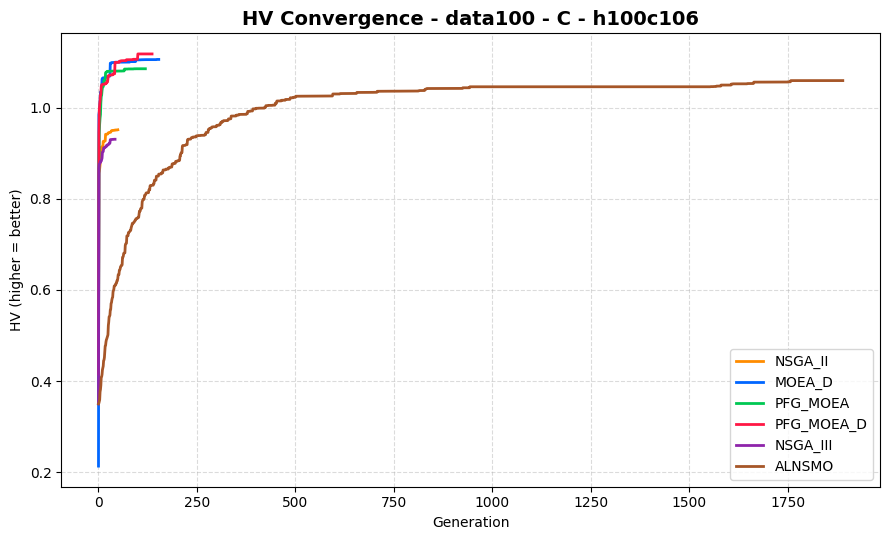

Loaded CSV: convergence_analysis\hv_convergence_data100_C_h100c106.csv
Saved PDF: convergence_analysis\hv_convergence_data100_C_h100c106.pdf


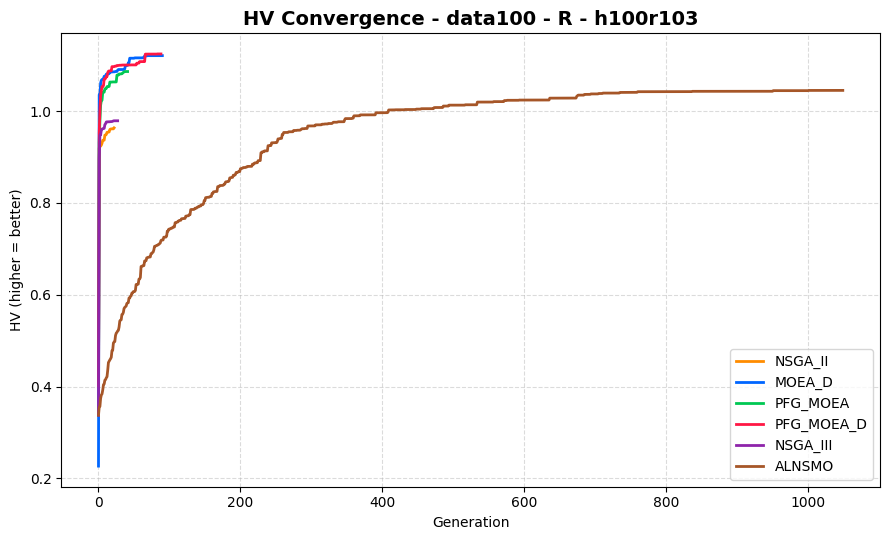

Loaded CSV: convergence_analysis\hv_convergence_data100_R_h100r103.csv
Saved PDF: convergence_analysis\hv_convergence_data100_R_h100r103.pdf


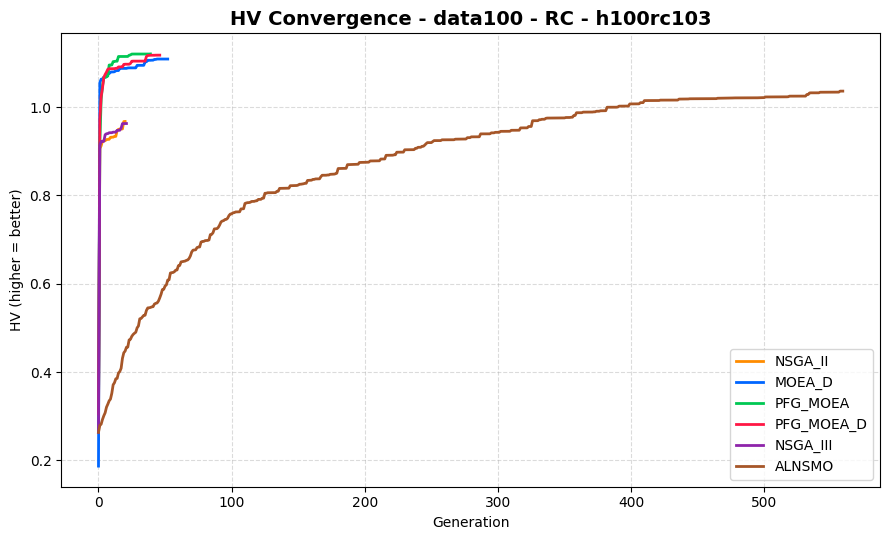

Loaded CSV: convergence_analysis\hv_convergence_data100_RC_h100rc103.csv
Saved PDF: convergence_analysis\hv_convergence_data100_RC_h100rc103.pdf


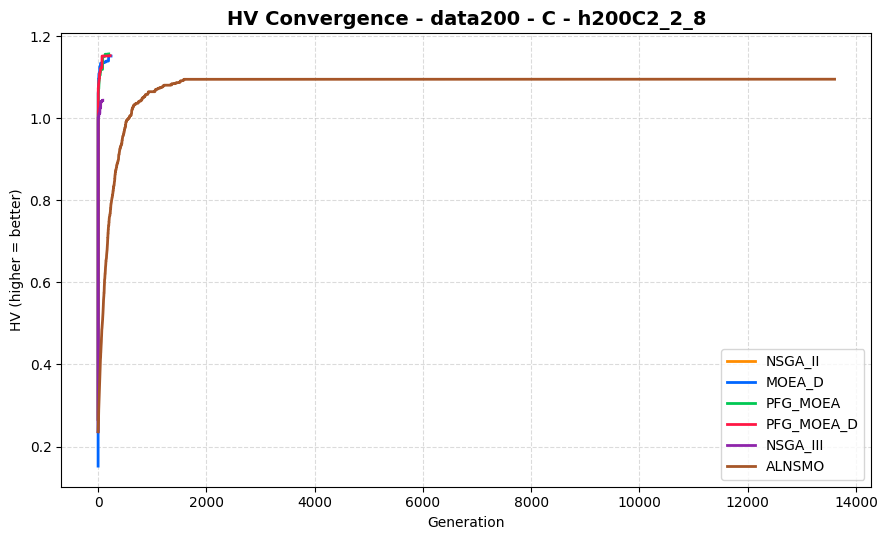

Loaded CSV: convergence_analysis\hv_convergence_data200_C_h200C2_2_8.csv
Saved PDF: convergence_analysis\hv_convergence_data200_C_h200C2_2_8.pdf
Total plotted: 4


dict_keys([('data100', 'C', 'h100c106'), ('data100', 'R', 'h100r103'), ('data100', 'RC', 'h100rc103'), ('data200', 'C', 'h200C2_2_8')])

In [2]:
# STEP 2: READ SAVED CSV LOGS, PLOT HV CONVERGENCE, AND SAVE PDF
# Cell này chạy độc lập sau khi đã có CSV từ STEP 1.
# Không chạy lại thuật toán, chỉ đọc trực tiếp các file CSV trong thư mục convergence_analysis.

import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"D:\codePython\pythonProject\final_project\pfg_moead_vrpd_ver2")
os.chdir(PROJECT_DIR)

OUTPUT_DIR = Path("convergence_analysis")

ALGOS = ["NSGA_II", "MOEA_D", "PFG_MOEA", "PFG_MOEA_D", "NSGA_III", "ALNSMO"]
COLORS = {
    "NSGA_II": "#ff8c00",
    "MOEA_D": "#0066ff",
    "PFG_MOEA": "#00c853",
    "PFG_MOEA_D": "#ff1744",
    "NSGA_III": "#8e24aa",
    "ALNSMO": "#a65628",
}


def safe_filename(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name))


def plot_convergence_from_csv(csv_file):
    metrics = pd.read_csv(csv_file)

    dataset_name = metrics["dataset"].iloc[0]
    group = metrics["group"].iloc[0]
    instance_name = metrics["instance"].iloc[0]

    plt.figure(figsize=(9, 5.5))

    for algo in ALGOS:
        data = metrics[metrics["algorithm"] == algo].sort_values("generation")
        if data.empty:
            continue

        plt.plot(
            data["generation"],
            data["HV"],
            label=algo,
            color=COLORS[algo],
            linewidth=2.0,
        )

    plt.title(f"HV Convergence - {dataset_name} - {group} - {instance_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Generation")
    plt.ylabel("HV (higher = better)")
    plt.grid(True, linestyle="--", alpha=0.45)
    plt.legend(fontsize=10)
    plt.tight_layout()

    pdf_file = OUTPUT_DIR / f"hv_convergence_{dataset_name}_{group}_{safe_filename(instance_name)}.pdf"
    plt.savefig(pdf_file, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    print("Loaded CSV:", csv_file)
    print("Saved PDF:", pdf_file)
    return metrics


csv_files = sorted(OUTPUT_DIR.glob("hv_convergence_*.csv"))

if not csv_files:
    print("No CSV files found. Run STEP 1 first.")
else:
    plotted_logs = {}

    for csv_file in csv_files:
        metrics = plot_convergence_from_csv(csv_file)
        dataset_name = metrics["dataset"].iloc[0]
        group = metrics["group"].iloc[0]
        instance_name = metrics["instance"].iloc[0]
        plotted_logs[(dataset_name, group, instance_name)] = metrics

    print("Total plotted:", len(plotted_logs))

plotted_logs.keys() if "plotted_logs" in globals() else []


## Ghi Chu HV

HV o day la Hypervolume cho bai toan minimization voi 2 muc tieu `makespan-carbon`. Truoc khi tinh HV, cac diem Pareto cua 6 thuat toan trong cung mot instance duoc min-max normalize chung de cac duong so sanh duoc voi nhau. Reference point la `[1.1, 1.1]`, lon hon mien chuan hoa 10%, nen HV co the lon hon `1.0` va tien gan `1.21` trong truong hop front phu rat tot vung chuan hoa.
